In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

adj_close    = pd.read_csv("./input/수정주가_현금배당반영.csv", index_col=0, parse_dates=True)
close        = pd.read_csv("./input/종가.csv", index_col=0, parse_dates=True)
share        = pd.read_csv("./input/상장주식수_보통주.csv", index_col=0, parse_dates=True)
pre_beta_df  = pd.read_csv("./output/pre_ranking_beta.csv", index_col=0, parse_dates=True)
mkt_returns  = pd.read_csv("./output/mkt_portfolio_ret.csv", index_col=0, parse_dates=True)
is_kospi_raw = pd.read_csv("./input/시장구분.csv", index_col=0, parse_dates=True)

In [2]:
ME_df       = close * share
is_kospi    = (is_kospi_raw == 'KS').astype(int)
monthly_ret = adj_close.pct_change(fill_method=None)

In [3]:
equity_consolidated = pd.read_csv("./input/자본총계_지배_연결.csv", index_col=0, parse_dates=True)
equity_separate     = pd.read_csv("./input/자본총계_지배_주재무제표.csv", index_col=0, parse_dates=True)

# 음수 자본은 NaN으로 처리
equity_consolidated = equity_consolidated.applymap(lambda x: x if x >= 0 else np.nan)
equity_separate     = equity_separate.applymap(lambda x: x if x >= 0 else np.nan)

In [4]:
BE_ME = ((equity_separate * 1000) / ME_df.loc[equity_separate.index]).iloc[:-2]

BE_ME_june = BE_ME.copy()
BE_ME_june.index = BE_ME_june.index + pd.offsets.MonthEnd(6)

BE_ME_june.loc[pd.Timestamp('2025-12-31')] = np.nan
BE_ME_june = BE_ME_june.sort_index()

In [5]:
june_ends = pd.to_datetime([f"{y}-06-30" for y in range(1999, 2025 + 1)])
june_ends = june_ends.append(pd.DatetimeIndex(['2025-12-31']))
june_ends

DatetimeIndex(['1999-06-30', '2000-06-30', '2001-06-30', '2002-06-30',
               '2003-06-30', '2004-06-30', '2005-06-30', '2006-06-30',
               '2007-06-30', '2008-06-30', '2009-06-30', '2010-06-30',
               '2011-06-30', '2012-06-30', '2013-06-30', '2014-06-30',
               '2015-06-30', '2016-06-30', '2017-06-30', '2018-06-30',
               '2019-06-30', '2020-06-30', '2021-06-30', '2022-06-30',
               '2023-06-30', '2024-06-30', '2025-06-30', '2025-12-31'],
              dtype='datetime64[ns]', freq=None)

In [6]:
assign_list    = []
port_ret_list  = []
port_char_list = []

for i in range(len(june_ends) - 1):
    start_date = june_ends[i]
    end_date   = june_ends[i + 1]

    # 1) 6월말 기준 원자료
    ME_t       = ME_df.loc[start_date]
    BE_ME_t = BE_ME_june.loc[start_date]
    is_kospi_t = is_kospi.loc[start_date]

    # 2) size breakpoint: pre_beta 유무와 무관하게 전체 KOSPI 종목 사용
    ME_kospi_all = ME_t[is_kospi_t == 1].dropna()
    size_breaks  = ME_kospi_all.quantile(np.arange(0.1, 1.0, 0.1)).values

    # 3) 분류 대상: ME와 BE_ME가 모두 있는 종목
    df = pd.DataFrame({
        'ME': ME_t,
        'BE_ME': BE_ME_t,
        'is_kospi': is_kospi_t
    }).dropna(subset=['ME', 'BE_ME']).copy()

    # 4) size decile 부여
    df['size_decile'] = pd.cut(
        df['ME'],
        bins=[-np.inf, *size_breaks, np.inf],
        labels=range(1, 11)
    )

    # 5) 각 size decile 내에서 KOSPI 종목만으로 BE_ME breakpoint 계산
    df['BE_ME_decile'] = np.nan

    for s in range(1, 11):
        kospi_in_size = df.loc[(df['size_decile'] == s) & (df['is_kospi'] == 1), 'BE_ME']
        beta_breaks = kospi_in_size.quantile(np.arange(0.1, 1.0, 0.1)).values

        mask = df['size_decile'] == s
        df.loc[mask, 'BE_ME_decile'] = pd.cut(
            df.loc[mask, 'BE_ME'],
            bins=[-np.inf, *beta_breaks, np.inf],
            labels=range(1, 11)
        ).astype(float)

    df = df.dropna(subset=['size_decile', 'BE_ME_decile']).copy()
    df['size_decile'] = df['size_decile'].astype(int)
    df['BE_ME_decile'] = df['BE_ME_decile'].astype(int)

    # 추가: 종목별 포트폴리오 배정 저장
    assign = (
        df.reset_index()
          .rename(columns={'index': 'Ticker'})
    )
    assign['Date'] = end_date
    assign_list.append(assign[['Date', 'Ticker', 'ME', 'BE_ME', 'is_kospi', 'size_decile', 'BE_ME_decile']])

    # 6) 보유기간 월별 수익률
    ret_window = monthly_ret.loc[start_date:end_date, df.index][1:]

    # 7) 포트폴리오별 월별 평균수익률 저장
    port_ret = (
        ret_window.T
        .join(df[['size_decile', 'BE_ME_decile']])
        .groupby(['size_decile', 'BE_ME_decile'])
        .mean()
        .T
        .stack([0, 1])
        .rename('ret')
        .reset_index()
        .rename(columns={'level_0': 'Date'})
    )
    port_ret_list.append(port_ret)

    # 8) start_date 기준 포트폴리오 특성치 저장
    port_char = (
        df.groupby(['size_decile', 'BE_ME_decile'])
          .agg(
              n_firms=('ME', 'size'),
              mean_lnME=('ME', lambda x: np.log(x).mean()),
              mean_BE_ME=('BE_ME', 'mean')
          )
          .reset_index()
    )
    port_char['Date'] = start_date
    port_char_list.append(port_char)

portfolio_assignment = pd.concat(assign_list, ignore_index=True)
portfolio_ret        = pd.concat(port_ret_list, ignore_index=True)
portfolio_chars      = pd.concat(port_char_list, ignore_index=True)

In [7]:
portfolio_ret

,Date,size_decile,BE_ME_decile,ret
0,1999-07-31,1,1,-0.095025
1,1999-07-31,1,2,-0.089062
2,1999-07-31,1,3,1.055263
3,1999-07-31,1,4,-0.698448
4,1999-07-31,1,5,0.107344
...,...,...,...,...
31795,2025-12-31,10,6,-0.001772
31796,2025-12-31,10,7,0.019598
31797,2025-12-31,10,8,0.025499
31798,2025-12-31,10,9,0.040969


In [8]:
# (1) 10x10 포트폴리오 wide
portfolio_ret_wide = (
    portfolio_ret
    .pivot(index='Date', columns=['size_decile', 'BE_ME_decile'], values='ret')
    .reindex(columns=pd.MultiIndex.from_product([range(1, 11), range(1, 11)]))
)

# (2) size별 전체 평균 (각 size 안에서 beta 1~10 평균)
size_all = {
    f'(Size {i}, ALL)': portfolio_ret_wide.loc[:, [(i, j) for j in range(1, 11)]].mean(axis=1)
    for i in range(1, 11)
}

# (3) beta별 전체 평균 (각 beta 안에서 size 1~10 평균)
beta_all = {
    f'(ALL, BE_ME {j})': portfolio_ret_wide.loc[:, [(i, j) for i in range(1, 11)]].mean(axis=1)
    for j in range(1, 11)
}

# (4) 전체 평균
all_all = pd.Series(
    portfolio_ret_wide.mean(axis=1),
    index=portfolio_ret_wide.index,
    name='(ALL, ALL)'
)

# (5) 기존 100개 컬럼 이름 변경
portfolio_ret_wide.columns = [f'({i}, {j})' for i, j in portfolio_ret_wide.columns]

# (6) 20개 + 1개 추가
portfolio_ret_wide = pd.concat(
    [
        portfolio_ret_wide,
        pd.DataFrame(size_all, index=portfolio_ret_wide.index),
        pd.DataFrame(beta_all, index=portfolio_ret_wide.index),
        all_all
    ],
    axis=1
)

In [9]:
portfolio_ret_mean = pd.DataFrame(
    index=['ALL'] + [f'Size {i}' for i in range(1, 11)],
    columns=['ALL'] + [f'BE_ME {j}' for j in range(1, 11)],
    dtype=float
)

# 10x10 셀
for i in range(1, 11):
    for j in range(1, 11):
        portfolio_ret_mean.loc[f'Size {i}', f'BE_ME {j}'] = portfolio_ret_wide[f'({i}, {j})'].mean() * 100

# 각 size별 ALL 열
for i in range(1, 11):
    portfolio_ret_mean.loc[f'Size {i}', 'ALL'] = portfolio_ret_wide[f'(Size {i}, ALL)'].mean() * 100

# 각 beta별 ALL 행
for j in range(1, 11):
    portfolio_ret_mean.loc['ALL', f'BE_ME {j}'] = portfolio_ret_wide[f'(ALL, BE_ME {j})'].mean() * 100

# 전체 ALL
portfolio_ret_mean.loc['ALL', 'ALL'] = portfolio_ret_wide['(ALL, ALL)'].mean() * 100

print("Size-BE_ME Portfolio Mean Returns:")
round(portfolio_ret_mean, 2)

Size-BE_ME Portfolio Mean Returns:


,ALL,BE_ME 1,BE_ME 2,BE_ME 3,BE_ME 4,BE_ME 5,BE_ME 6,BE_ME 7,BE_ME 8,BE_ME 9,BE_ME 10
ALL,1.34,0.46,0.89,1.13,1.44,1.27,1.56,1.58,1.62,1.75,1.71
Size 1,3.12,1.85,2.96,3.06,4.10,2.97,3.39,3.90,3.36,3.06,2.56
Size 2,2.07,0.95,1.49,1.73,2.06,1.85,2.90,2.13,2.37,2.83,2.42
Size 3,1.37,0.47,1.25,1.26,1.15,1.41,1.30,1.43,1.61,2.10,1.72
Size 4,1.31,-0.00,0.50,1.21,1.43,1.44,1.61,1.70,1.80,1.88,1.52
Size 5,1.07,0.42,0.73,0.52,1.15,1.04,1.24,1.15,1.22,1.54,1.66
Size 6,0.94,0.19,0.61,0.72,0.69,0.46,1.00,1.32,1.49,1.29,1.59
Size 7,0.84,0.14,0.44,0.39,0.81,0.77,0.99,1.02,1.13,1.04,1.66
Size 8,0.88,0.03,0.12,0.94,0.86,0.89,0.98,0.96,1.51,1.16,1.41
Size 9,0.85,0.10,0.37,0.51,0.91,1.06,1.05,1.10,0.94,1.28,1.23


Average Returns by BE/ME Decile for All Sizes


<Axes: title={'center': 'Average Returns by BE/ME Decile (All Sizes)'}, ylabel='Average Return (%)'>

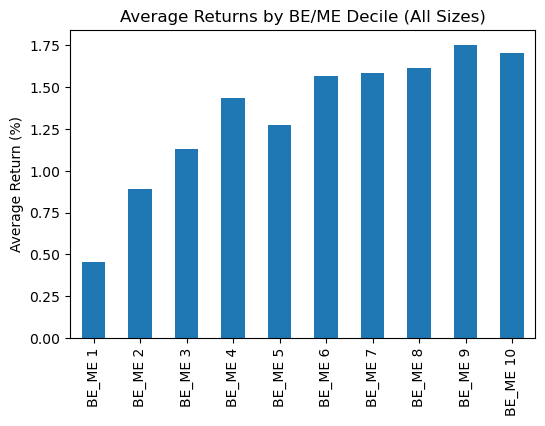

In [10]:
print("Average Returns by BE/ME Decile for All Sizes")
portfolio_ret_mean.loc['ALL'][1:].plot(kind='bar', figsize=(6, 4), title='Average Returns by BE/ME Decile (All Sizes)', ylabel='Average Return (%)')

Average Returns by Size Decile for All BE/ME...


<Axes: title={'center': 'Average Returns by Size Decile (All BE/ME)'}, ylabel='Average Return (%)'>

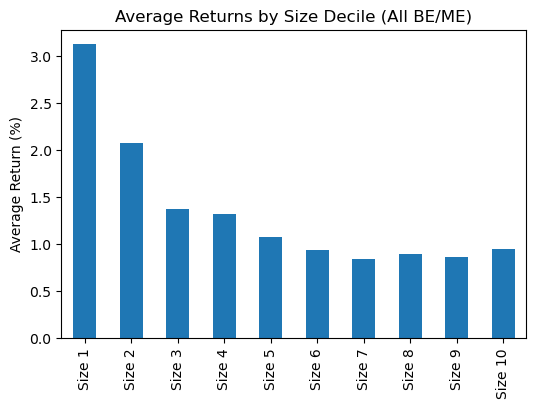

In [11]:
print("Average Returns by Size Decile for All BE/ME...")
portfolio_ret_mean['ALL'].iloc[1:].plot(kind='bar', figsize=(6, 4), title='Average Returns by Size Decile (All BE/ME)', ylabel='Average Return (%)')